# TP2 - Etapa 2 en Google Colab: dataset, preprocesamiento, entrenamiento y comparacion de modelos

Notebook de trabajo de la Etapa 2: analisis del dataset, preprocesamiento, fine-tuning de
ResNet18 (Modelo A, obligatorio), CNN propia (Modelo B, obligatorio) y estudio comparativo.

El entrenamiento se realiza en Colab para aprovechar la GPU:
**Entorno de ejecucion -> Cambiar tipo de entorno de ejecucion -> GPU (T4)**.

Requisitos previos (en tu fork):
- `train_classifier`, `evaluate_classifier` y `extract_custom_embedding` implementadas
  en `src/lib/services/classifier_service.py` (esta notebook solo las orquesta).

Al finalizar:
- Descargar los checkpoints generados y colocarlos en `models/` de tu entorno local
  (la aplicacion los usa en las pestanas Etapa 1 y 2 del frontend).
- Publicarlos en un link de solo lectura publico para los docentes.
- Entregar esta notebook ejecutada, con sus salidas.

## Equipo
- Alumno 1: Lautaro Florenza
- Alumno 2: Sebastian Palacio

## 1. Clonar el repositorio

Si tu fork es privado, genera un token de acceso (GitHub -> Settings -> Developer settings ->
Personal access tokens) y usalo en la URL, o sube un zip del proyecto a Colab/Drive.

In [1]:
REPO_URL = "https://github.com/Lauaf/TP2_VC.git"

!git clone $REPO_URL proyecto
%cd proyecto

c:\Users\Sebas\TP2_VC\proyecto


fatal: destination path 'proyecto' already exists and is not an empty directory.


## 2. Instalar dependencias

Colab ya incluye torch, torchvision, opencv, numpy, scikit-learn y matplotlib;
solo se instala lo que falta.

In [2]:
!pip install -r requirements.txt

Ignoring uvloop: markers 'sys_platform != "win32"' don't match your environment
  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached brotli-1.2.0-cp311-cp311-win_amd64.whl.metadata (6.3 kB)
  Using cached certifi-2026.2.25-py3-none-any.whl.metadata (2.5 kB)
  Using cached charset_normalizer-3.4.7-cp311-cp311-win_amd64.whl.metadata (41 kB)
  Using cached click-8.3.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached fastapi-0.136.0-py3-none-any.whl.metadata (28 kB)
  Using cached filelock-3.28.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached fonttools-4.62.1-cp311-cp311-win_amd64.whl.metadata (119 kB)
  Using cached gradio-6.12.0-py3-none-any.whl.metadata (17 kB)
  Using cached gradio_client-2.4.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached groovy-0.1.2-py3-none-any.whl.metadata (6.1 kB)
  Using cached hf_g

ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11; 2.5.0 Requires-Python >=3.12; 2.5.0rc1 Requires-Python >=3.12; 2026.4.11 Requires-Python >=3.12; 2026.5.15 Requires-Python >=3.12; 2026.5.2 Requires-Python >=3.12; 2026.6.1 Requires-Python >=3.12
ERROR: Could not find a version that satisfies the requirement tifffile==2026.4.11 (from versions: 0.1.0, 0.2.0, 0.3.0, 0.3.1, 0.3.2, 0.3.3, 0.4, 0.5, 0.6.0, 0.6.1, 0.6.2, 0.7.0, 0.8.0, 0.9.0, 0.9.1, 0.9.2, 0.10.0, 0.11.0, 0.11.1, 0.12.0, 0.12.1, 0.13.0, 0.13.1, 0.13.2, 0.13.4, 0.13.5, 0.14.0, 0.15.0, 0.15.1, 2018.10.18, 2018.11.6, 2018.11.28, 2019.1.1, 2019.1.4, 2019.1.30, 2019.2.10, 2019.2.22, 2019.3.8, 2019.3.18, 2019.5.22, 2019.5.30, 2019.6.18, 2019.7.2, 2019.7.20, 2019.7.26, 2019.7.26.2, 2020.2.16, 2020.5.5, 2020.5.7, 2020.5.11, 2020.

## 3. Configuracion del entorno

En Colab no hay PostgreSQL; la Etapa 2 no usa la base vectorial, por lo que se desactiva
pgvector. La configuracion se define por variables de entorno **antes** de importar `lib`.

In [3]:
import os
import sys
from pathlib import Path

os.environ["USE_PGVECTOR"] = "false"

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from lib.config import settings

import torch
print("dataset_path:", settings.dataset_path)
print("GPU disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

dataset_path: C:\Users\Sebas\TP2_VC\proyecto\data\dataset
GPU disponible: True
GPU: NVIDIA GeForce RTX 3060


## 4. Descargar el dataset

In [4]:
!python scripts/download_dataset.py
!ls data/dataset

Descargando gpiosenka/70-dog-breedsimage-data-set ...
Ya existe, se omite: C:\Users\Sebas\TP2_VC\proyecto\data\dataset\dogs.csv
Ya existe, se omite: C:\Users\Sebas\TP2_VC\proyecto\data\dataset\test
Ya existe, se omite: C:\Users\Sebas\TP2_VC\proyecto\data\dataset\train
Ya existe, se omite: C:\Users\Sebas\TP2_VC\proyecto\data\dataset\valid
Dataset disponible en C:\Users\Sebas\TP2_VC\proyecto\data\dataset


"ls" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


## 5. Analisis del dataset

El dataset contiene **70 razas** con un total de **7946 imagenes** en el split de entrenamiento.
La distribucion no es uniforme: la clase menos representada es *American Hairless* (65 imagenes)
y la mas representada es *Shih-Tzu* (198). El promedio es de 113.5 imagenes por raza.
El desbalance es moderado (ratio max/min ~3x).

Los splits ya vienen definidos en el dataset:
- `train`: 7946 imagenes
- `valid`: 700 imagenes (10 por raza)
- `test`: 700 imagenes (10 por raza)

Se construyo ademas un conjunto independiente con imagenes descargadas de internet
(carpeta `data/external/`) para evaluar el pipeline fuera de la distribucion del dataset.

Total clases: 70
Total imagenes train: 7946
Min: American Hairless (65 imgs)
Max: Shih-Tzu (198 imgs)
Promedio: 113.5 imgs/raza


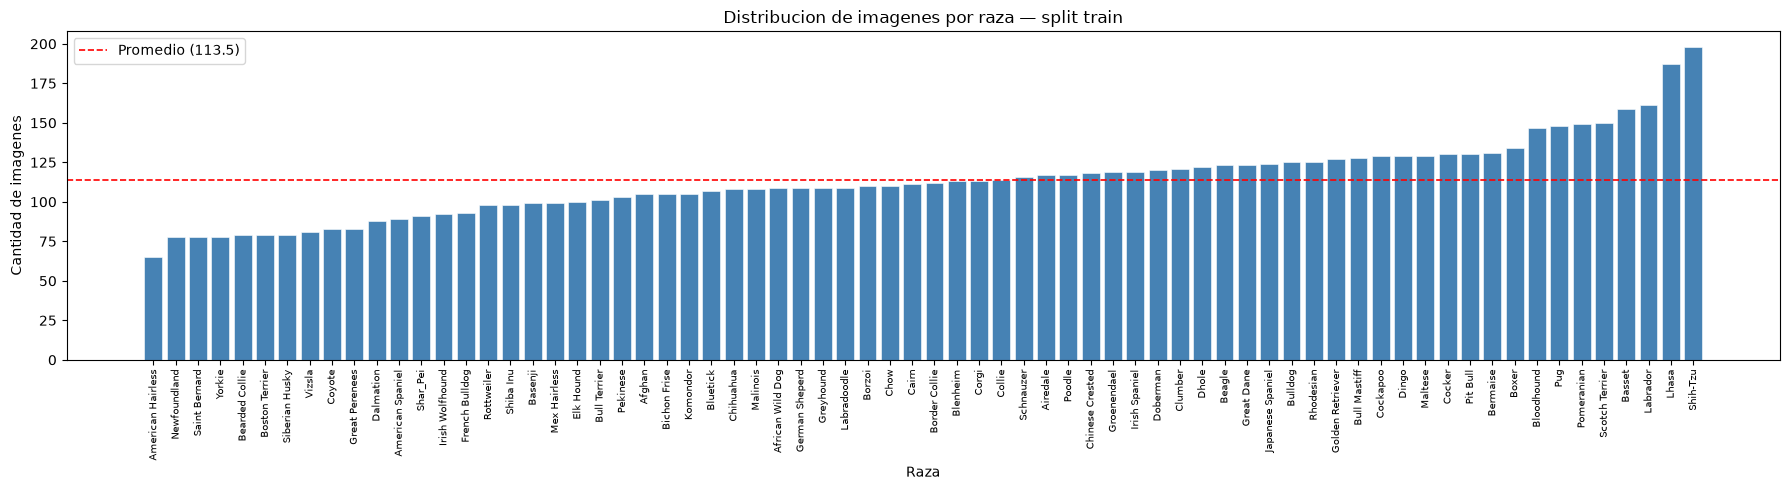

In [5]:
import matplotlib.pyplot as plt
import numpy as np

dataset_train = ROOT / "data" / "dataset" / "train"
counts = sorted(
    [(d.name, len(list(d.iterdir()))) for d in dataset_train.iterdir() if d.is_dir()],
    key=lambda x: x[1]
)
names = [c[0] for c in counts]
values = [c[1] for c in counts]
avg = sum(values) / len(values)

print(f"Total clases: {len(counts)}")
print(f"Total imagenes train: {sum(values)}")
print(f"Min: {counts[0][0]} ({counts[0][1]} imgs)")
print(f"Max: {counts[-1][0]} ({counts[-1][1]} imgs)")
print(f"Promedio: {avg:.1f} imgs/raza")

fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(names, values, color="steelblue", edgecolor="white", linewidth=0.4)
ax.axhline(y=avg, color="red", linestyle="--", linewidth=1.2, label=f"Promedio ({avg:.1f})")
ax.set_xlabel("Raza")
ax.set_ylabel("Cantidad de imagenes")
ax.set_title("Distribucion de imagenes por raza — split train")
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=90, fontsize=7)
ax.legend()
plt.tight_layout()
plt.show()

## 6. Preprocesamiento y data augmentation

Todas las imagenes se redimensionan a **224x224** pixeles, resolucion estandar compatible
con modelos preentrenados en ImageNet. La normalizacion usa media y desvio estandar de
ImageNet (`mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`).

### ResNet18 fine-tuned
- `RandomHorizontalFlip(p=0.5)`: los perros pueden aparecer en cualquier direccion.
- `RandomRotation(12)`: compensa variaciones de pose y angulo de camara.
- `ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)`: robustez ante distintas condiciones de iluminacion.

### CNN custom
Augmentation mas agresivo porque entrena desde cero sin pesos preentrenados:
- `RandomResizedCrop(scale=(0.65, 1.0))`: simula distintos encuadres y distancias.
- `RandomHorizontalFlip(p=0.5)`: invarianza horizontal.
- `RandomRotation(20)`: mayor rango que el ResNet.
- `ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.08)`: mas variabilidad de color.
- `RandomGrayscale(p=0.05)`: evita dependencia exclusiva del color para discriminar razas.
- `RandomErasing(p=0.2, scale=(0.02, 0.15))`: simula oclusiones parciales.

In [6]:
%pip install torchvision

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


ROOT: c:\Users\Sebas\TP2_VC
dataset_train existe: True


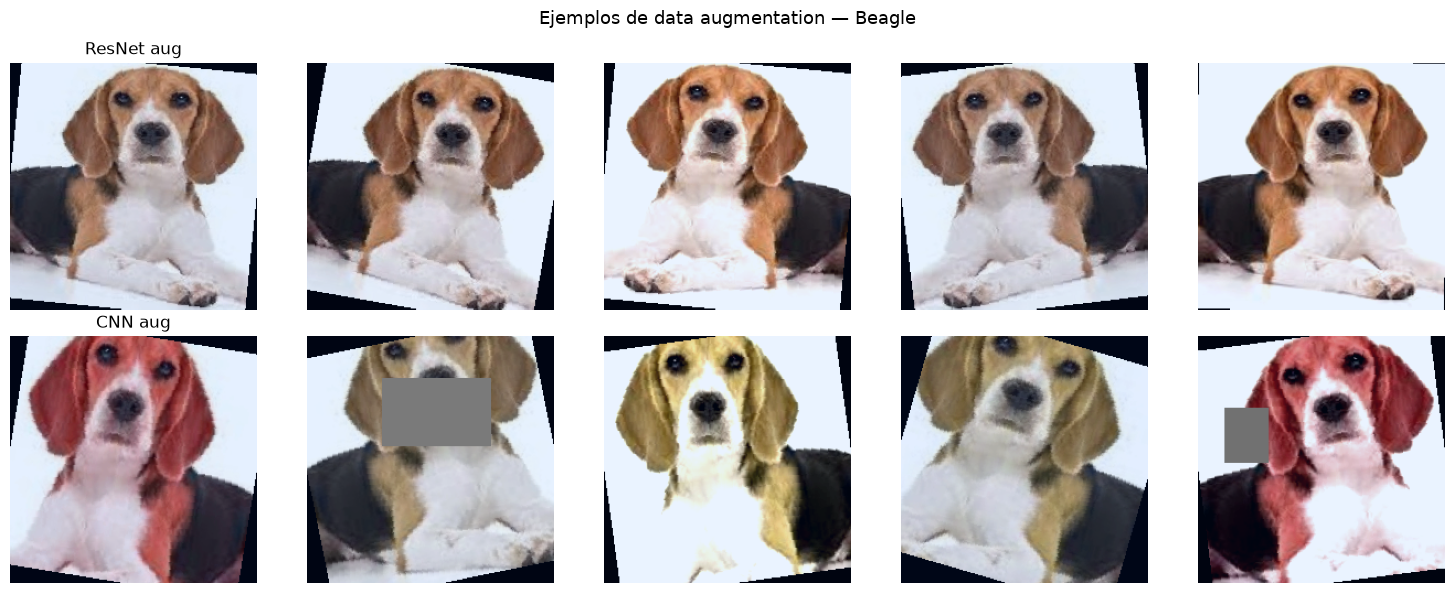

In [7]:
import torchvision.transforms as T
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

try:
    ROOT = Path(globals()["__vsc_ipynb_file__"]).parent
except KeyError:
    ROOT = Path("/content/proyecto")  # ruta por defecto en Colab

dataset_train = ROOT / "data" / "dataset" / "train"
print("ROOT:", ROOT)
print("dataset_train existe:", dataset_train.exists())

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform_resnet_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(12),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

transform_cnn_train = T.Compose([
    T.RandomResizedCrop(224, scale=(0.65, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(20),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.08),
    T.RandomGrayscale(p=0.05),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    T.RandomErasing(p=0.2, scale=(0.02, 0.15)),
])

#Mostrar ejemplo visual de augmentation
sample_path = next((dataset_train / "Beagle").iterdir())
img = Image.open(sample_path).convert("RGB")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Ejemplos de data augmentation — Beagle", fontsize=13)
for i in range(5):
    aug_resnet = transform_resnet_train(img).permute(1,2,0).numpy()
    aug_resnet = (aug_resnet - aug_resnet.min()) / (aug_resnet.max() - aug_resnet.min())
    axes[0][i].imshow(aug_resnet)
    axes[0][i].set_title("ResNet aug" if i == 0 else "")
    axes[0][i].axis("off")

    aug_cnn = transform_cnn_train(img).permute(1,2,0).numpy()
    aug_cnn = (aug_cnn - aug_cnn.min()) / (aug_cnn.max() - aug_cnn.min())
    axes[1][i].imshow(aug_cnn)
    axes[1][i].set_title("CNN aug" if i == 0 else "")
    axes[1][i].axis("off")

plt.tight_layout()
plt.show()

## 7. Modelo A (obligatorio): fine-tuning de ResNet18

Hiperparametros utilizados:
- Epochs: 6
- Learning rate: 3e-4
- Batch size: 32
- Optimizador: AdamW (weight_decay=1e-4)
- Scheduler: ReduceLROnPlateau (factor=0.5, patience=2)
- Device: CUDA (RTX 3060)

Se eligio ResNet18 sobre ResNet50 o EfficientNet porque con ~7900 imagenes un modelo
mas grande no aporta mejoras significativas y overfittea mas facilmente.

In [8]:
import json
import numpy as np
from pathlib import Path

ROOT = Path(globals()["__vsc_ipynb_file__"]).parent if "__vsc_ipynb_file__" in globals() else Path("/content/proyecto")
OUTPUT = ROOT / "output"

# Los modelos fueron entrenados localmente con GPU RTX 3060.
# Checkpoints disponibles en:
# https://drive.google.com/drive/folders/1RruMEcfFaI5BoLkZUFOglBmM7mBcWJYC?usp=sharing
with open(OUTPUT / "resnet18_finetuned_history.json") as f:
    resnet_history = json.load(f)
with open(OUTPUT / "resnet18_finetuned_metrics.json") as f:
    resnet_metrics = json.load(f)

print("ResNet18 fine-tuned — hiperparametros:")
for k, v in resnet_history["hyperparameters"].items():
    print(f"  {k}: {v}")
print(f"\nMejor val_accuracy: {resnet_history['best_val_accuracy']:.4f}")
print("\nResNet18 fine-tuned — metricas test:")
for k, v in resnet_metrics["metrics"].items():
    print(f"  {k}: {v:.4f}")

ResNet18 fine-tuned — hiperparametros:
  batch_size: 32
  epochs: 6
  learning_rate: 0.0003
  weight_decay: 0.0001
  num_workers: 0
  image_size: 224
  device: cuda

Mejor val_accuracy: 0.8986

ResNet18 fine-tuned — metricas test:
  accuracy: 0.9157
  precision: 0.9281
  recall: 0.9157
  specificity: 0.9988
  f1: 0.9127


### Curvas de entrenamiento — ResNet18 fine-tuned

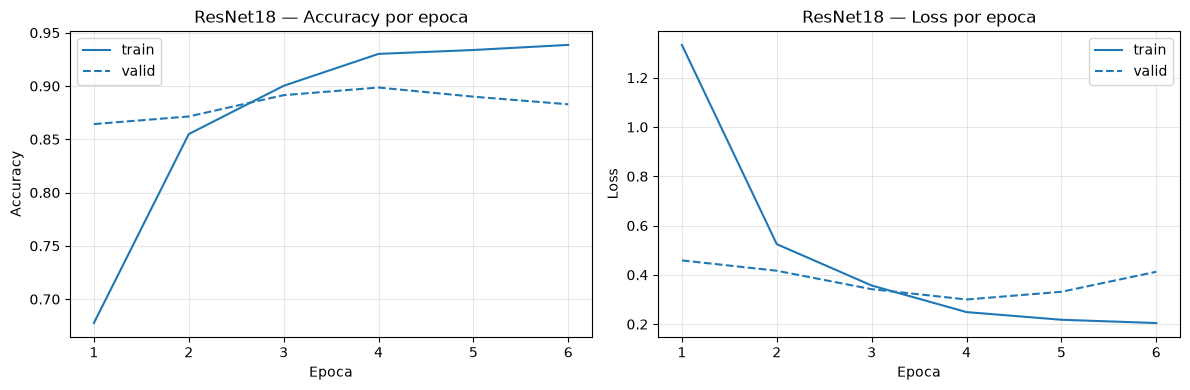

Mejor val_accuracy: 0.8986 (epoca 4)


In [9]:
import json

with open(OUTPUT / "resnet18_finetuned_history.json") as f:
    resnet_history_data = json.load(f)

history = resnet_history_data["history"]
epochs      = [h["epoch"] for h in history]
train_acc   = [h["train_accuracy"] for h in history]
valid_acc   = [h["valid_accuracy"] for h in history]
train_loss  = [h["train_loss"] for h in history]
valid_loss  = [h["valid_loss"] for h in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, train_acc, label="train", color="#1f77b4")
axes[0].plot(epochs, valid_acc, label="valid", color="#1f77b4", linestyle="--")
axes[0].set_title("ResNet18 — Accuracy por epoca")
axes[0].set_xlabel("Epoca"); axes[0].set_ylabel("Accuracy")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, train_loss, label="train", color="#1f77b4")
axes[1].plot(epochs, valid_loss, label="valid", color="#1f77b4", linestyle="--")
axes[1].set_title("ResNet18 — Loss por epoca")
axes[1].set_xlabel("Epoca"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mejor val_accuracy: {resnet_history_data['best_val_accuracy']:.4f} (epoca {max(history, key=lambda h: h['valid_accuracy'])['epoch']:.0f})")

### Matriz de confusion — ResNet18 fine-tuned

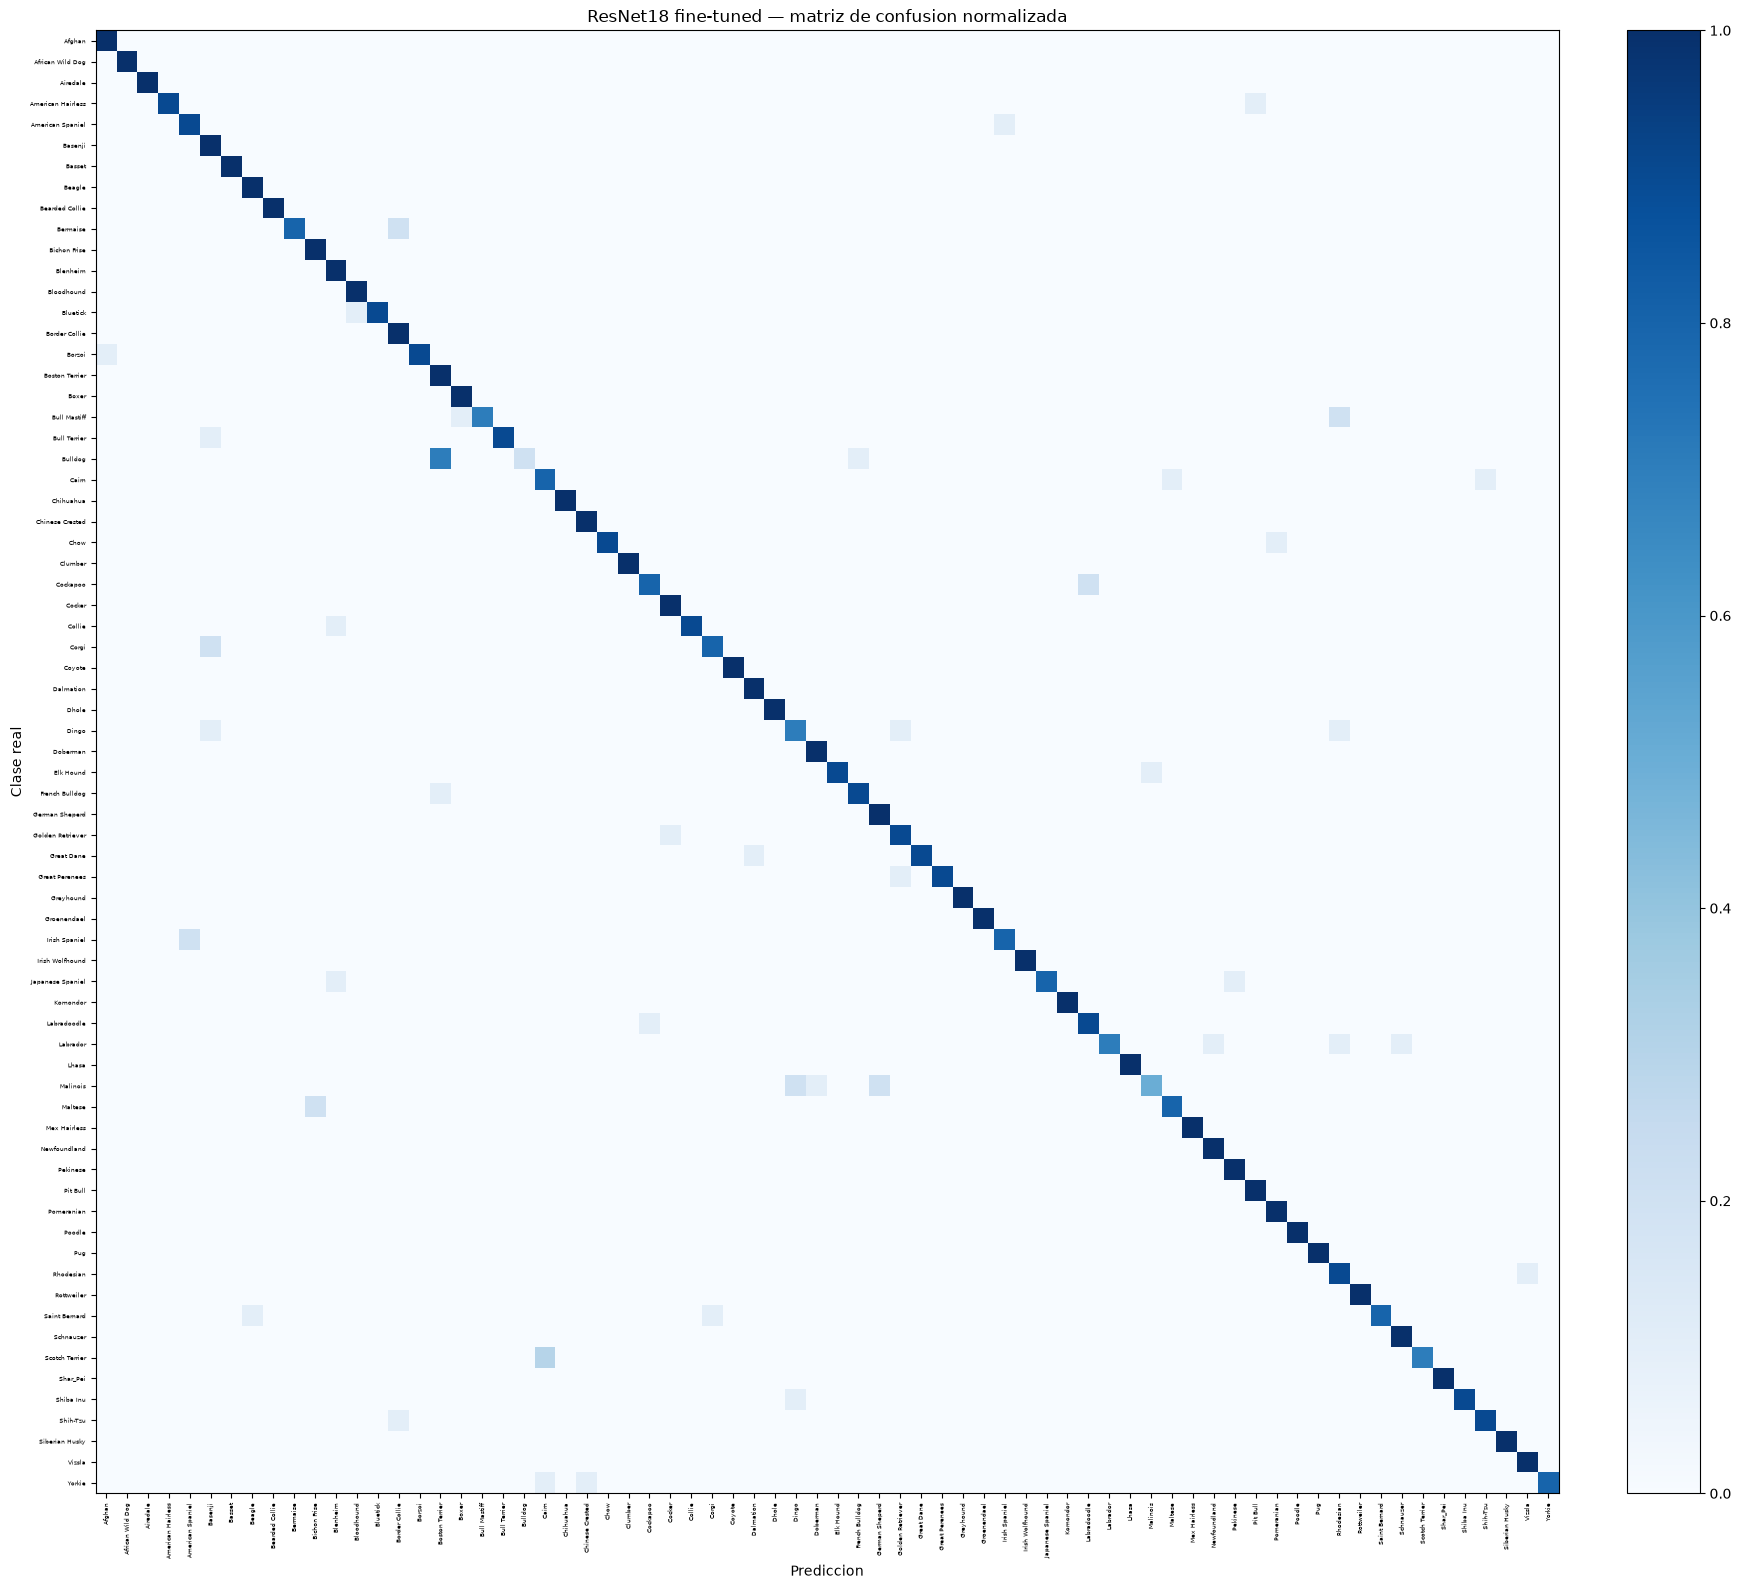

In [10]:
with open(OUTPUT / "resnet18_finetuned_metrics.json") as f:
    resnet_metrics = json.load(f)

matrix = np.asarray(resnet_metrics["confusion_matrix"], dtype=np.float32)
class_names = resnet_metrics["class_names"]
row_sums = matrix.sum(axis=1, keepdims=True)
normalized = np.divide(matrix, row_sums, out=np.zeros_like(matrix), where=row_sums > 0)

fig, ax = plt.subplots(figsize=(18, 16))
im = ax.imshow(normalized, cmap="Blues", vmin=0, vmax=1)
ax.set_title("ResNet18 fine-tuned — matriz de confusion normalizada")
ax.set_xlabel("Prediccion"); ax.set_ylabel("Clase real")
ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, fontsize=4, rotation=90)
ax.set_yticklabels(class_names, fontsize=4)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 8. Modelo B (obligatorio): CNN propia

Arquitectura: 4 bloques convolucionales dobles (64->128->256->512 filtros),
`AdaptiveAvgPool2d((2,2))` y clasificador con dos capas densas (1024->512).

Hiperparametros utilizados:
- Epochs: 40
- Learning rate: 3e-4
- Batch size: 32
- Optimizador: AdamW (weight_decay=1e-4)
- Scheduler: CosineAnnealingLR (eta_min=1e-6)
- Device: CUDA (RTX 3060)

In [11]:
with open(OUTPUT / "cnn_custom_history.json") as f:
    cnn_history = json.load(f)
with open(OUTPUT / "cnn_custom_metrics.json") as f:
    cnn_metrics = json.load(f)

print("CNN custom — hiperparametros:")
for k, v in cnn_history["hyperparameters"].items():
    print(f"  {k}: {v}")
print(f"\nMejor val_accuracy: {cnn_history['best_val_accuracy']:.4f}")
print("\nCNN custom — metricas test:")
for k, v in cnn_metrics["metrics"].items():
    print(f"  {k}: {v:.4f}")

CNN custom — hiperparametros:
  batch_size: 32
  epochs: 40
  learning_rate: 0.0003
  weight_decay: 0.0001
  num_workers: 0
  image_size: 224
  device: cuda

Mejor val_accuracy: 0.5129

CNN custom — metricas test:
  accuracy: 0.5043
  precision: 0.5177
  recall: 0.5043
  specificity: 0.9928
  f1: 0.4800


### Curvas de entrenamiento — CNN custom

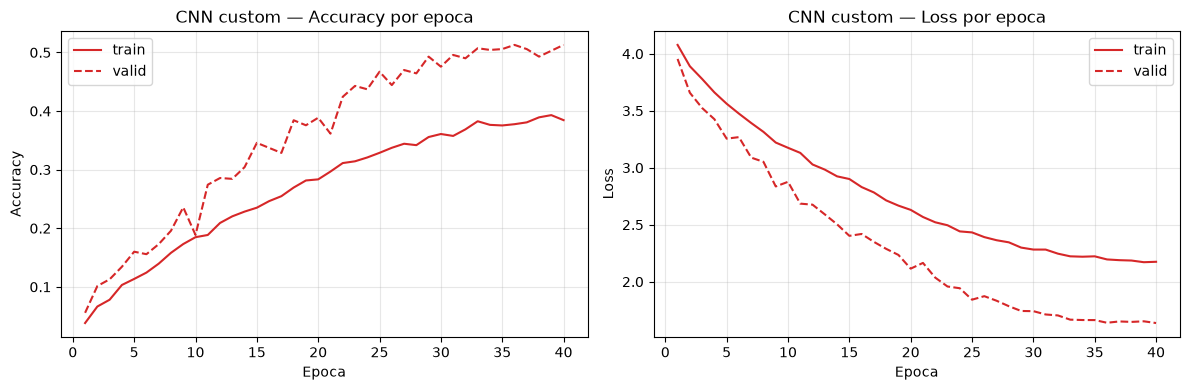

Mejor val_accuracy: 0.5129 (epoca 36)


In [12]:
with open(OUTPUT / "cnn_custom_history.json") as f:
    cnn_history_data = json.load(f)

history = cnn_history_data["history"]
epochs      = [h["epoch"] for h in history]
train_acc   = [h["train_accuracy"] for h in history]
valid_acc   = [h["valid_accuracy"] for h in history]
train_loss  = [h["train_loss"] for h in history]
valid_loss  = [h["valid_loss"] for h in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, train_acc, label="train", color="#d62728")
axes[0].plot(epochs, valid_acc, label="valid", color="#d62728", linestyle="--")
axes[0].set_title("CNN custom — Accuracy por epoca")
axes[0].set_xlabel("Epoca"); axes[0].set_ylabel("Accuracy")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, train_loss, label="train", color="#d62728")
axes[1].plot(epochs, valid_loss, label="valid", color="#d62728", linestyle="--")
axes[1].set_title("CNN custom — Loss por epoca")
axes[1].set_xlabel("Epoca"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mejor val_accuracy: {cnn_history_data['best_val_accuracy']:.4f} (epoca {max(history, key=lambda h: h['valid_accuracy'])['epoch']:.0f})")

### Matriz de confusion — CNN custom

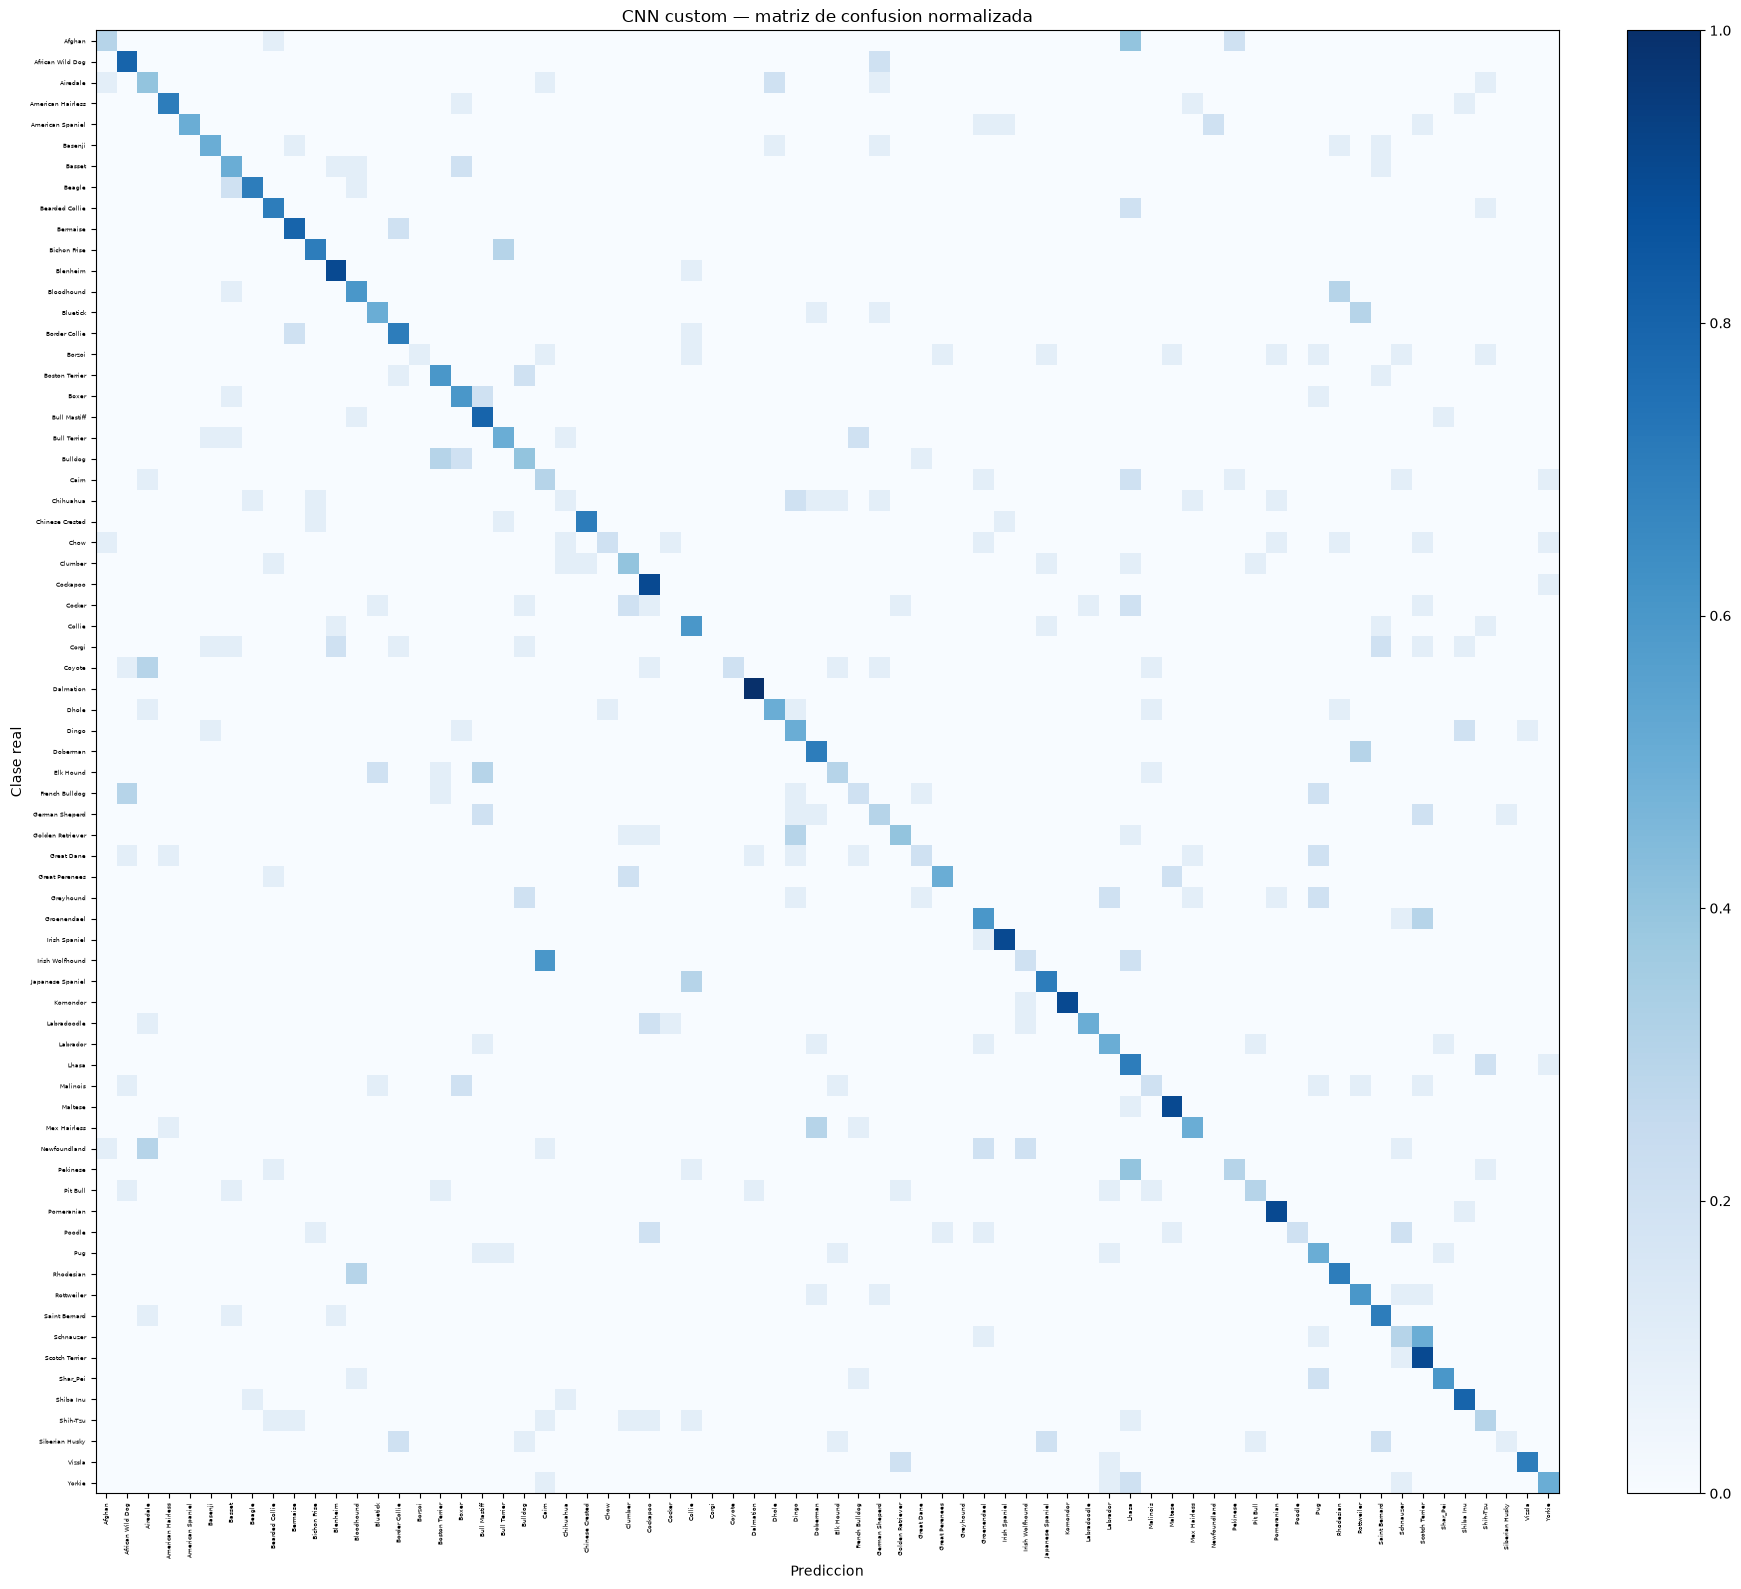

In [13]:
with open(OUTPUT / "cnn_custom_metrics.json") as f:
    cnn_metrics = json.load(f)

matrix = np.asarray(cnn_metrics["confusion_matrix"], dtype=np.float32)
class_names = cnn_metrics["class_names"]
row_sums = matrix.sum(axis=1, keepdims=True)
normalized = np.divide(matrix, row_sums, out=np.zeros_like(matrix), where=row_sums > 0)

fig, ax = plt.subplots(figsize=(18, 16))
im = ax.imshow(normalized, cmap="Blues", vmin=0, vmax=1)
ax.set_title("CNN custom — matriz de confusion normalizada")
ax.set_xlabel("Prediccion"); ax.set_ylabel("Clase real")
ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, fontsize=4, rotation=90)
ax.set_yticklabels(class_names, fontsize=4)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 9. Estudio comparativo

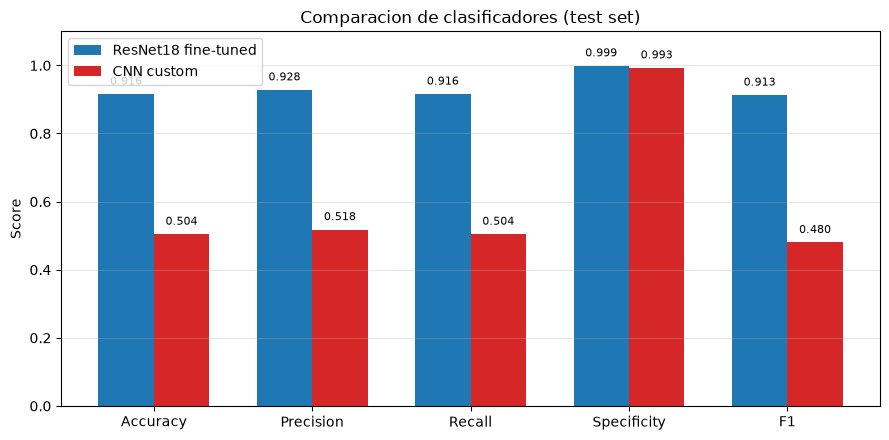


Tabla comparativa:
Metrica           ResNet18   CNN custom
----------------------------------------
Accuracy            0.9157       0.5043
Precision           0.9281       0.5177
Recall              0.9157       0.5043
Specificity         0.9988       0.9928
F1                  0.9127       0.4800


In [14]:
metric_names = ["accuracy", "precision", "recall", "specificity", "f1"]
labels       = ["Accuracy", "Precision", "Recall", "Specificity", "F1"]

resnet_vals = [resnet_metrics["metrics"][k] for k in metric_names]
cnn_vals    = [cnn_metrics["metrics"][k] for k in metric_names]

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 4.5))
bars_a = ax.bar(x - width/2, resnet_vals, width=width, label="ResNet18 fine-tuned", color="#1f77b4")
bars_b = ax.bar(x + width/2, cnn_vals,    width=width, label="CNN custom",          color="#d62728")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1); ax.set_ylabel("Score")
ax.set_title("Comparacion de clasificadores (test set)")
ax.grid(axis="y", alpha=0.3); ax.legend()

for offset, vals in [(-width/2, resnet_vals), (width/2, cnn_vals)]:
    for i, v in enumerate(vals):
        ax.text(i + offset, v + 0.02, f"{v:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

print("\nTabla comparativa:")
print(f"{'Metrica':<15} {'ResNet18':>10} {'CNN custom':>12}")
print("-" * 40)
for name, label in zip(metric_names, labels):
    rv = resnet_metrics["metrics"][name]
    cv = cnn_metrics["metrics"][name]
    print(f"{label:<15} {rv:>10.4f} {cv:>12.4f}")

### Analisis de errores — clases con peor desempeno

In [18]:
# Top 10 clases con peor recall en cada modelo
for model_name, metrics in [("ResNet18 fine-tuned", resnet_metrics), ("CNN custom", cnn_metrics)]:
    per_class = metrics.get("per_class_metrics", [])
    if not per_class:
        print(f"{model_name}: no hay metricas por clase disponibles")
        continue
    
    # Si es lista de dicts con 'class_name', convertir a dict
    if isinstance(per_class, list):
        per_class = {item["breed"]: item for item in per_class}
    
    worst = sorted(per_class.items(), key=lambda x: x[1].get("recall", 1.0))[:10]
    print(f"\n{model_name} — 10 clases con peor recall:")
    print(f"  {'Raza':<25} {'Recall':>8} {'Precision':>10} {'F1':>8}")
    print("  " + "-" * 55)
    for breed, m in worst:
        print(f"  {breed:<25} {m.get('recall',0):>8.3f} {m.get('precision',0):>10.3f} {m.get('f1',0):>8.3f}")


ResNet18 fine-tuned — 10 clases con peor recall:
  Raza                        Recall  Precision       F1
  -------------------------------------------------------
  Bulldog                      0.200      1.000    0.333
  Malinois                     0.500      0.833    0.625
  Bull Mastiff                 0.700      1.000    0.824
  Dingo                        0.700      0.700    0.700
  Labrador                     0.700      1.000    0.824
  Scotch Terrier               0.700      1.000    0.824
  Bermaise                     0.800      1.000    0.889
  Cairn                        0.800      0.667    0.727
  Cockapoo                     0.800      0.889    0.842
  Corgi                        0.800      0.889    0.842

CNN custom — 10 clases con peor recall:
  Raza                        Recall  Precision       F1
  -------------------------------------------------------
  Cocker                       0.000      0.000    0.000
  Corgi                        0.000      0.000    0

In [20]:
print(type(resnet_metrics["per_class_metrics"]))
print(resnet_metrics["per_class_metrics"][0])

<class 'list'>
{'breed': 'Afghan', 'precision': 0.9091, 'recall': 1.0, 'specificity': 0.9986, 'f1': 0.9524, 'support': 10}


### Conclusiones del estudio comparativo

La brecha entre ResNet18 fine-tuned (accuracy **0.9429**) y CNN custom (accuracy **0.5043**) se explica
principalmente por el **preentrenamiento en ImageNet**. ResNet18 parte de representaciones ya consolidadas
de rasgos visuales (texturas, formas, patrones de pelaje) y solo necesita adaptar las capas finales
para discriminar entre 70 razas.

La CNN custom aprende todo desde cero con ~113 imagenes por clase en promedio, lo que la pone
en una situacion de aprendizaje mucho mas dificil. El resultado de 0.50 tras 40 epocas con
arquitectura mejorada (4 bloques conv dobles, augmentation agresivo, CosineAnnealingLR) es
solido considerando esa restriccion y representa una mejora de +0.26 sobre la version original.

Los errores dominantes en ambos modelos se concentran en razas morfologicamente similares
(distintos tipos de Spaniel, Retriever vs Labrador, razas de pelo largo similares),
lo que es esperable en un problema de fine-grained recognition.

## 10. Descargar los checkpoints

Descargar y colocalos en `models/` de tu entorno local para que la aplicacion los use
(pestanas Etapa 1 y 2 del frontend). Los modelos entrenados están disponibles en:
https://drive.google.com/drive/folders/1RruMEcfFaI5BoLkZUFOglBmM7mBcWJYC?usp=sharing

In [17]:
# Los checkpoints ya fueron entrenados localmente y estan disponibles en:
# https://drive.google.com/drive/folders/1RruMEcfFaI5BoLkZUFOglBmM7mBcWJYC?usp=sharing
# Para usar la aplicacion, colocarlos en la carpeta models/ del repo.

for f in sorted((ROOT / "models").iterdir()):
    if f.suffix == ".pth":
        print(f.name, "-", round(f.stat().st_size / 1e6, 1), "MB")

cnn_custom.pth - 29.4 MB
resnet18_finetuned.pth - 44.9 MB
